# Analisis de un experimento A/B de una página de internet

## Objetivo:



In [1]:
# Importar librerías
import pandas as pd
from pathlib import Path
from scipy.stats import ttest_ind, levene
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations                              #Librería para realizar iteraciones entre elementos de una lista

# ── Constante global ────────────────────────────────────────────────────────
ALPHA = 0.05

# ── Rutas centralizadas (ajustar según entorno) ──────────────────────────────
BASE_DIR = Path(r"C:\Users\JGO Gamer\Documents\Projects\Exercise-landing-experiment-synthetic")
PATH_DF1 = BASE_DIR / "landing-experiment-synthetic.csv"
PATH_DF2 = BASE_DIR / "landing-experiment-synthetic_2.csv"
PATH_DF3 = BASE_DIR / "landing-experiment-synthetic_3.csv"

# ── Carga de datos ───────────────────────────────────────────────────────────
df  = pd.read_csv(PATH_DF1)
df2 = pd.read_csv(PATH_DF2)
df3 = pd.read_csv(PATH_DF3)

## Exploración de los datos

In [2]:
# Exploración inicial
print('Información general')
print(df.info())
print()
print('Lista de conteo de valores únicos')
print(df.nunique().sort_values(ascending=False))
print()
print('Tabla muestra del dataset')
df.head()

Información general
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_usuario   25000 non-null  str    
 1   pagina       25000 non-null  str    
 2   region       25000 non-null  str    
 3   dispositivo  25000 non-null  str    
 4   conversion   25000 non-null  int64  
 5   gasto        25000 non-null  float64
 6   clics        25000 non-null  int64  
dtypes: float64(1), int64(2), str(4)
memory usage: 1.3 MB
None

Lista de conteo de valores únicos
id_usuario     25000
gasto           2722
clics             92
region             3
pagina             2
conversion         2
dispositivo        2
dtype: int64

Tabla muestra del dataset


,id_usuario,pagina,region,dispositivo,conversion,gasto,clics
0,99aa92e9-6dc3-4b18-8a31-fb1442e71d67,A,Norte,Desktop,0,0.00,0
1,99182f6f-325f-499a-815e-5ad414fe1600,B,Norte,Mobile,1,102.86,92
2,774a1f0c-eadb-4c1e-ae10-3058c9594162,B,Centro,Mobile,0,0.00,0
3,6bcc6b1b-56ee-4a7c-b478-01147c2d2cf9,B,Sur,Desktop,0,0.00,0
4,b22abbb3-9919-4974-9288-41212563492c,A,Centro,Mobile,1,76.38,68


### Clasificación de las columnas de acuerdo al tipo de dato (numérico, booleano o categórico)

In [3]:
def clasificar_columnas(df):
    """Clasifica columnas en numéricas, booleanas y categóricas."""

    columnas_ignorar = ['id_usuario']

    numericas, booleanas, categoricas = [], [], []

    for col in df.columns:

        #Condición para ignorar columnas
        if col in columnas_ignorar:
            continue

        valores_unicos = df[col].dropna().nunique()
        if valores_unicos <= 2:
            booleanas.append(col)
        elif pd.api.types.is_numeric_dtype(df[col]):
            numericas.append(col)
        else:
            categoricas.append(col)

    return list(df.columns), numericas, booleanas, categoricas

# Llamada única — resultado reutilizado en todas las celdas siguientes
todas_columnas, numericas, booleanas, categoricas = clasificar_columnas(df)

# Tabla de clasificación con dict comprehension (un solo bucle)
mapeo_clasificacion = (
    {col: 'Numerica'   for col in numericas}
    | {col: 'Booleana'  for col in booleanas}
    | {col: 'Categórica' for col in categoricas}
)

tabla_variables = (
    pd.DataFrame(mapeo_clasificacion.items(), columns=['Columna', 'Tipo de variable'])
    .sort_values('Tipo de variable')
    .reset_index(drop=True)  # drop=True evita columna de índice redundante
)

print('Clasificación de las columnas')
display(tabla_variables)

Clasificación de las columnas


,Columna,Tipo de variable
0,pagina,Booleana
1,dispositivo,Booleana
2,conversion,Booleana
3,region,Categórica
4,gasto,Numerica
5,clics,Numerica


### Estadísticas descriptivas de variables numéricas

In [4]:
print('OBTENCIÓN DE LA MEDIANA')
print(df[numericas].median())
print()
print('OBTENCIÓN DE LA ESTADÍSTICA DESCRIPTIVA: COLUMNAS NUMÉRICAS')
print(df[numericas].describe())

OBTENCIÓN DE LA MEDIANA
gasto    0.0
clics    0.0
dtype: float64

OBTENCIÓN DE LA ESTADÍSTICA DESCRIPTIVA: COLUMNAS NUMÉRICAS
              gasto         clics
count  25000.000000  25000.000000
mean       9.124518      8.573600
std       22.627903     21.302419
min        0.000000      0.000000
25%        0.000000      0.000000
50%        0.000000      0.000000
75%        0.000000      0.000000
max      111.970000    103.000000


### Estadísticas descriptivas de variables categóricas

In [5]:
print('OBTENCIÓN DE LA ESTADÍSTICA DESCRIPTIVA: COLUMNAS CATEGÓRICAS')
print(df[categoricas].describe())

OBTENCIÓN DE LA ESTADÍSTICA DESCRIPTIVA: COLUMNAS CATEGÓRICAS
       region
count   25000
unique      3
top     Norte
freq    10170


## Aplicación estadística t-test para comparar promedios

### Objetivo: Comparar el gasto promedio entre usuarios de las dos páginas.

Responder la siguiente pregunta: ¿El gasto promedio de los clientes es diferente entre la pagina A y la pagina B?

* Hipótesis nula (H₀): El gasto promedio es igual en ambas paginas.

* Hipótesis alternativa (H₁): El gasto promedio es diferente entre las paginas.



### Creación de la función t-test 

In [6]:
def prueba_estadistica_t(col1, col2, nombre_col1='grupo_1', nombre_col2='grupo_2'):
    """Aplica Levene + t-Welch o t-Student según igualdad de varianzas.

    Parámetros
    ----------
    lista1 : array-like — Asignación de la primera columna
    lista2 : array-like — Asignación de la segunda columna
    lista3 : array-like — Asignación del nombre de la primera columna, colocar comilla sencillo o doble
    lista4 : array-like — Asignación del nombre de la segunda columna, colocar comilla sencillo o doble
    """

    def _imprimir_promedios():
        """Bloque de promedios reutilizable (antes duplicado en ambas ramas)."""
        media_1 = round(col1.mean(), 2)
        media_2 = round(col2.mean(), 2)
        print('Rechazo de la hipótesis nula: hay una evidencia de una diferencia')
        print()
        print('Promedios')
        print(f'  {nombre_col1} : {media_1}')
        print(f'  {nombre_col2} : {media_2}')
        print(f'  diferencia_media : {round(media_1 - media_2, 2)}')

    # Prueba de Levene (igualdad de varianzas)
    l_stat, p_value_var = levene(col1, col2)
    print('Resultado de la prueba estadística de levene (varianzas iguales)')
    print(f'  Estadístico de levene: {l_stat}')
    print(f'  Valor p: {p_value_var}')
    print()

    varianzas_iguales = p_value_var > ALPHA   # True → t-Student / False → t-Welch
    nombre_prueba = 't-test' if varianzas_iguales else 't-welch'

    if varianzas_iguales:
        print('Conclusión: No rechazamos H₀ de varianzas → equal_var=True (t-Student)')
    else:
        print('Conclusión: Rechazamos H₀ de varianzas → equal_var=False (t-Welch)')

    # Prueba t (rama única, parámetro equal_var determinado arriba)
    t_stat, p_value = ttest_ind(col1, col2, equal_var=varianzas_iguales)
    print()
    print(f'Resultado de la prueba estadística {nombre_prueba}')
    print(f'  Estadístico t: {t_stat}')
    print(f'  Valor p: {p_value}')
    print()
    print('Conclusión:')

    if p_value <= ALPHA:
        _imprimir_promedios()
    else:
        print('No se rechaza la hipótesis nula: no hay evidencia de una diferencia')

### Primer estudio: gasto por pagina (usuarios que compraron)

In [7]:
# Filtración base por página de prueba que si compraron

pag_a_filt = (df['pagina']=='A') & (df['conversion']==1)
pag_b_filt = (df['pagina']=='B') & (df['conversion']==1)

#Selección de la columna de interés
pagina_a = df[pag_a_filt]['gasto']
pagina_b = df[pag_b_filt]['gasto']

# Validar separación de grupos
display(pagina_a.head())
pagina_b.head()

# Aplicación de la prueba t-test
prueba_estadistica_t(pagina_a, pagina_b, "pagina_a", "pagina_b")

4     76.38
19    68.02
23    48.39
29    65.73
42    78.24
Name: gasto, dtype: float64

Resultado de la prueba estadística de levene (varianzas iguales)
  Estadístico de levene: 0.2541046488631795
  Valor p: 0.6142294194590157

Conclusión: No rechazamos H₀ de varianzas → equal_var=True (t-Student)

Resultado de la prueba estadística t-test
  Estadístico t: -20.74768675846578
  Valor p: 1.4282455772283267e-90

Conclusión:
Rechazo de la hipótesis nula: hay una evidencia de una diferencia

Promedios
  pagina_a : 55.54
  pagina_b : 65.68
  diferencia_media : -10.14


#### Conclusión
Resultado estadísticamente significativo, ya que hay un cambio en el promedio con respecto a la página B, ya que la diferencia de la media es negativo (B->A)

### Segundo estudio: gasto por dispositivo y por clics realizados (usuarios que compraron)

In [8]:
# Filtración base por dispositivos que si compraron
disp_desk_filt = (df['dispositivo'] == 'Desktop') & (df['conversion'] == 1)
disp_mobi_filt = (df['dispositivo'] == 'Mobile') & (df['conversion'] == 1)

#Selección de la columna de interés
desktop = df[disp_desk_filt]['clics']
mobile  = df[disp_mobi_filt]['clics']

# Validar separación de grupos
display(desktop.head())
mobile.head()

# Aplicación de la prueba t-test
prueba_estadistica_t(desktop, mobile, 'desktop', 'mobile')

23    48
25    56
27    94
30    63
43    82
Name: clics, dtype: int64

Resultado de la prueba estadística de levene (varianzas iguales)
  Estadístico de levene: 29.375202305086287
  Valor p: 6.342079953198224e-08

Conclusión: Rechazamos H₀ de varianzas → equal_var=False (t-Welch)

Resultado de la prueba estadística t-welch
  Estadístico t: 11.812680654202826
  Valor p: 1.4477922204452494e-31

Conclusión:
Rechazo de la hipótesis nula: hay una evidencia de una diferencia

Promedios
  desktop : 60.83
  mobile : 54.97
  diferencia_media : 5.86


#### Conclusión: 
Resultado estadísticamente significativo, ya que en promedio se observa mayor clics en desktop

### Tercer estudio: por región centro que si convirtieron (usuarios que compraron)

In [9]:
# Filtración base por dispositivos que si compraron en la región centro
disp_desk_filt = (df['dispositivo'] == 'Desktop') & (df['conversion'] == 1) & (df['region'] == 'Centro')
disp_mobi_filt = (df['dispositivo'] == 'Mobile') & (df['conversion'] == 1) & (df['region'] == 'Centro')


#Selección de la columna de interés
desktop = df[disp_desk_filt]['clics']
mobile  = df[disp_mobi_filt]['clics']

# Validar separación de grupos
display(desktop.head())
mobile.head()

# Aplicación de la prueba t-test
prueba_estadistica_t(desktop, mobile, 'desktop', 'mobile')

23     48
25     56
30     63
243    57
264    65
Name: clics, dtype: int64

Resultado de la prueba estadística de levene (varianzas iguales)
  Estadístico de levene: 11.824747635224542
  Valor p: 0.000602875298871451

Conclusión: Rechazamos H₀ de varianzas → equal_var=False (t-Welch)

Resultado de la prueba estadística t-welch
  Estadístico t: 6.172057672784738
  Valor p: 9.195201448983437e-10

Conclusión:
Rechazo de la hipótesis nula: hay una evidencia de una diferencia

Promedios
  desktop : 60.61
  mobile : 55.51
  diferencia_media : 5.1


#### Conclusión: 

1️⃣ *¿Hay evidencia de una diferencia?** Con base en la prueba t, sí existe diferencia estadísticamente significativo.

2️⃣ *¿En qué dirección?** La diferencia de clics en la región centro es mayor en Desktop.

3️⃣ *Limitaciones:** El resultado se basa en los resultados obtenidos del experimento entre las dos páginas evaluadas.

Con base en una  prueba t de dos muestras independientes, encontramos evidencia estadística de una diferencia en el gasto promedio entre las paginas A y B.

En promedio, los usuarios que convirtieron en la pagina B gastaron más que los de la pagina A.

Este resultado se basa en una muestra de usuarios que realizaron una compra y no evalúa si la diferencia observada es suficiente para justificar un cambio desde una perspectiva de negocio.

## Aplicación estadística z-test para proporciones

### Objetivo: determinar cual de la dos páginas tiene mayor conversión de compra.

Responder la siguiente pregunta: ¿en cuál de las dos paginas hay mayor conversión a compra?

* **H₀:** La tasa de conversión es igual en ambas páginas.
* **H₁:** La tasa de conversión es diferente entre ambas páginas.

### Creación de la función z-test

In [10]:
def prueba_z_test(exitos_n, observaciones_n, elemento_a='elemento_a', elemento_b='elemento_b'):
       
        """Prueba z de proporciones.

        Parámetros
        ----------
        lista1 : array-like — conteo de éxitos por grupo [A, B]
        lista2 : array-like — conteo total de observaciones por grupo [A, B]
        """
        z_stat, p_value = proportions_ztest(exitos_n, observaciones_n)

        print('Matriz a usar')
        print(f'Total conversión {elemento_a}:', exitos_n)
        print(f'Total conteo {elemento_b}   :', observaciones_n)
        print()
        print('Resultado de la prueba estadística z-test')
        print(f'  Estadístico z: {z_stat}')
        print(f'  Valor p      : {p_value}')
        print()
        print('Conclusión:')

        if p_value <= ALPHA:
            print('Rechazamos la hipótesis nula: hay una evidencia de una diferencia')

            # Usa los parámetros de la función (antes usaba variables globales — bug corregido)
            tasa_A = exitos_n[0] / observaciones_n[0]
            tasa_B = exitos_n[1] / observaciones_n[1]

            print()
            print('Distribución del porcentaje')
            print(f'  Tasa de conversión {elemento_a}: {tasa_A:.2%}')
            print(f'  Tasa de conversión {elemento_b}: {tasa_B:.2%}')
            print()
            print('Conclusión:')

            if tasa_A > tasa_B:
                print(f'{elemento_a} tiene mayor tasa de conversión ({tasa_A - tasa_B:.2%})')
            elif tasa_B > tasa_A:
                print(f'{elemento_b} tiene mayor tasa de conversión ({tasa_B - tasa_A:.2%})')
            else:
                print('Los elementos evaluados tienen la misma tasa de conversión')
        else:
            print('No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia')

### Primer estudio: tasa de conversión por página

#### Aplicación de la función z-test

In [11]:
#Extracción de estadísticas de conversión
conversion_stats_by_user_type = (
    df
    .groupby('pagina')['conversion']
    .agg(['sum','count'])
    .rename(columns={'sum':'conversiones', 'count': 'total_usuarios'})
)

# Matriz para usarlo en la prueba t-test
exitos        = [conversion_stats_by_user_type.loc['A', 'conversiones'], conversion_stats_by_user_type.loc['B', 'conversiones']]
observaciones = [conversion_stats_by_user_type.loc['A', 'total_usuarios'], conversion_stats_by_user_type.loc['B', 'total_usuarios']]

# Aplicación de la función z-test
prueba_z_test(exitos, observaciones, 'Página A', 'Página B')


Matriz a usar
Total conversión Página A: [np.int64(1626), np.int64(2098)]
Total conteo Página B   : [np.int64(12438), np.int64(12562)]

Resultado de la prueba estadística z-test
  Estadístico z: -8.056205645899977
  Valor p      : 7.869918925208132e-16

Conclusión:
Rechazamos la hipótesis nula: hay una evidencia de una diferencia

Distribución del porcentaje
  Tasa de conversión Página A: 13.07%
  Tasa de conversión Página B: 16.70%

Conclusión:
Página B tiene mayor tasa de conversión (3.63%)


#### Conclusión: 
Resultado estadísticamente significativo ( p <=0.05 ), ya que los datos proporcionan evidencia suficiente y afirmar que las tasas de conversión no son iguales siendo ligeramente mayor hacia la página B, por lo que recomiendo analizar si el costo de implementación vale la pena.

### Segundo estudio: tasa de conversión con columna de texto binario (Sí/No)

In [12]:
# Para este estudio se usa el df2, cargado al inicio.

#Método 1: Se filtra por conversión igual a 'Si'

conv_si_filt_1 = df2[df2['conversion']=="Si"]
print('Tabla de conversión igual a "Si"')
display(conv_si_filt_1.head())

#Contabilización de cuantos usuarios convirtieron (conversión = Si)
conversiones_2A = conv_si_filt_1.groupby('pagina')['conversion'].count()
print('Resultado del conteo (Método 1)')
display(conversiones_2A)

Tabla de conversión igual a "Si"


,id_usuario,pagina,region,dispositivo,conversion,gasto,clics
1,99182f6f-325f-499a-815e-5ad414fe1600,B,Norte,Mobile,Si,102.86,92
4,b22abbb3-9919-4974-9288-41212563492c,A,Centro,Mobile,Si,76.38,68
8,5992c5a1-554c-4e03-9b25-b2dd107266ed,B,Norte,Mobile,Si,66.89,60
19,d6ee3314-53e9-4926-90c0-382dd8671bb3,A,Sur,Mobile,Si,68.02,61
23,95140ec1-6763-4fbb-96b1-c9d6ccc2e93f,A,Centro,Desktop,Si,48.39,48


Resultado del conteo (Método 1)


pagina
A    1626
B    2098
Name: conversion, dtype: int64

In [13]:
#Método 2: creación de una columna nueva remplazando 'Si' = 1

df2['conversion_num'] = df2['conversion'].map({'Si': 1, 'No': 0})
print('Tabla con nueva columna numérica binaria')
display(df2.head())

#Suma de cuantos compraron con la nueva columna
conversiones_2B = df2.groupby('pagina')['conversion_num'].sum()
print('Resultado del conteo (Método 2)')
display(conversiones_2B)

Tabla con nueva columna numérica binaria


,id_usuario,pagina,region,dispositivo,conversion,gasto,clics,conversion_num
0,99aa92e9-6dc3-4b18-8a31-fb1442e71d67,A,Norte,Desktop,No,0.00,0,0
1,99182f6f-325f-499a-815e-5ad414fe1600,B,Norte,Mobile,Si,102.86,92,1
2,774a1f0c-eadb-4c1e-ae10-3058c9594162,B,Centro,Mobile,No,0.00,0,0
3,6bcc6b1b-56ee-4a7c-b478-01147c2d2cf9,B,Sur,Desktop,No,0.00,0,0
4,b22abbb3-9919-4974-9288-41212563492c,A,Centro,Mobile,Si,76.38,68,1


Resultado del conteo (Método 2)


pagina
A    1626
B    2098
Name: conversion_num, dtype: int64

In [14]:
#Contabilización de cuantos usuarios participaron
totales2 = df2.groupby('pagina')['conversion'].count()

# Método 1
exitos2A      = [conversiones_2A['A'], conversiones_2A['B']]
observaciones2 = [totales2['A'], totales2['B']]

print('=== Método 1 ===')
prueba_z_test(exitos2A, observaciones2, 'página A', 'página B')

# Método 2
exitos2B = [conversiones_2B['A'], conversiones_2B['B']]

print()
print('=== Método 2 ===')
prueba_z_test(exitos2B, observaciones2, 'página A', 'página B')

=== Método 1 ===
Matriz a usar
Total conversión página A: [np.int64(1626), np.int64(2098)]
Total conteo página B   : [np.int64(12438), np.int64(12562)]

Resultado de la prueba estadística z-test
  Estadístico z: -8.056205645899977
  Valor p      : 7.869918925208132e-16

Conclusión:
Rechazamos la hipótesis nula: hay una evidencia de una diferencia

Distribución del porcentaje
  Tasa de conversión página A: 13.07%
  Tasa de conversión página B: 16.70%

Conclusión:
página B tiene mayor tasa de conversión (3.63%)

=== Método 2 ===
Matriz a usar
Total conversión página A: [np.int64(1626), np.int64(2098)]
Total conteo página B   : [np.int64(12438), np.int64(12562)]

Resultado de la prueba estadística z-test
  Estadístico z: -8.056205645899977
  Valor p      : 7.869918925208132e-16

Conclusión:
Rechazamos la hipótesis nula: hay una evidencia de una diferencia

Distribución del porcentaje
  Tasa de conversión página A: 13.07%
  Tasa de conversión página B: 16.70%

Conclusión:
página B tiene ma

#### Conclusión: 

Con respecto a los diferentes métodos: ambos métodos producen el mismo resultado, confirmando que se puede aplicar z-test aunque la columna contenga texto binario.

Con respecto al resultado del estudio

1️⃣ ¿Hay evidencia de una diferencia? 

Con base en un z-test para proporciones, encontramos evidencia estadística de que la tasa de conversión difiere entre la página A y la página B.

2️⃣ ¿En qué dirección va la diferencia?

La página B presenta una tasa de conversión 3.63% mayor que la página A.
Tasa de conversión página A → 13.07%
Tasa de conversión página B → 16.70%

3️⃣ ¿Qué limitaciones o supuestos debo mencionar?

El resultado se basa en una muestra de usuarios.
La conversión se mide como evento binario (sí / no).
El análisis asume observaciones independientes.
No se evalúa aquí si la diferencia justifica un cambio de negocio.

Con base en en una prueba z para proporciones, encontramos evidencia estadística de una diferencia en la tasa de conversión entre las páginas A y B.

En particular, la página B muestra una tasa de conversión mayor que la página A.

Este resultado se basa en una muestra de usuarios y no evalúa si la magnitud de la diferencia es suficiente para justificar una decisión de negocio.

### Tercer estudio: tasa de conversión por dispositivo en región Norte

In [15]:
# Definición de la función base a usar
df_norte = df[df['region'] == 'Norte']

#Agrupar la columna a analizar, seleccionar la columna de interés para sumar y contabilizar
conversiones = df_norte.groupby('dispositivo')['conversion'].sum()
totales      = df_norte.groupby('dispositivo')['conversion'].count()

#Creación de la matriz
exitos       = [conversiones['Desktop'], conversiones['Mobile']]
observaciones = [totales['Desktop'], totales['Mobile']]

#Aplicar la función z-test
prueba_z_test(exitos, observaciones, 'Desktop', 'Mobile')

Matriz a usar
Total conversión Desktop: [np.int64(661), np.int64(889)]
Total conteo Mobile   : [np.int64(4020), np.int64(6150)]

Resultado de la prueba estadística z-test
  Estadístico z: 2.726459479847496
  Valor p      : 0.006401781230356481

Conclusión:
Rechazamos la hipótesis nula: hay una evidencia de una diferencia

Distribución del porcentaje
  Tasa de conversión Desktop: 16.44%
  Tasa de conversión Mobile: 14.46%

Conclusión:
Desktop tiene mayor tasa de conversión (1.99%)


In [16]:
#Los siguientes códigos son para iterar las opciones de una lista para aplicar la función z-test

#Consulta 1: asignar manualmente los dos elementos a evaluar

# Definición de la función base a usar
df_norte     = df[df['region'] == 'Norte']

#Seleccionar la columna de interés para sumar y contabilizar
dispositivos = df_norte['dispositivo'].unique().tolist()

# Verifica que las columnas esperadas existan
assert len(dispositivos) == 2, \
    f"Se esperaban 2 dispositivos, se encontraron: {len(dispositivos)}: {dispositivos}"

conversiones_n = (
    df_norte.groupby('dispositivo')['conversion']
    .sum()
    .reindex(dispositivos, fill_value=0)
)

totales_n = (
    df_norte.groupby('dispositivo')['conversion']
    .count()
    .reindex(dispositivos, fill_value=0)
)

exitos_n        = [conversiones_n.loc[d] for d in dispositivos]
observaciones_n = [totales_n.loc[d]      for d in dispositivos]

prueba_z_test(exitos_n, observaciones_n,  'Desktop', 'Mobile')

Matriz a usar
Total conversión Desktop: [np.int64(661), np.int64(889)]
Total conteo Mobile   : [np.int64(4020), np.int64(6150)]

Resultado de la prueba estadística z-test
  Estadístico z: 2.726459479847496
  Valor p      : 0.006401781230356481

Conclusión:
Rechazamos la hipótesis nula: hay una evidencia de una diferencia

Distribución del porcentaje
  Tasa de conversión Desktop: 16.44%
  Tasa de conversión Mobile: 14.46%

Conclusión:
Desktop tiene mayor tasa de conversión (1.99%)


In [17]:
# Consulta iterando todos los dispositivos que hay en el estudio para la región norte

# Definición de la función base a usar
df_norte     = df[df['region'] == 'Norte']

#Seleccionar la columna de interés para sumar y contabilizar
dispositivos = df_norte['dispositivo'].unique().tolist()

for disp_a, disp_b in combinations(dispositivos, 2):
    
    grupo_a = df_norte[df_norte['dispositivo'] == disp_a]
    grupo_b = df_norte[df_norte['dispositivo'] == disp_b]

    exitos_n        = [grupo_a['conversion'].sum(),   grupo_b['conversion'].sum()]
    observaciones_n = [grupo_a['conversion'].count(), grupo_b['conversion'].count()]

    print(f'\n{"="*50}')
    print(f'  {disp_a}  vs  {disp_b}')
    print(f'{"="*50}')
    prueba_z_test(exitos_n, observaciones_n, 'Desktop', 'Mobile')




  Desktop  vs  Mobile
Matriz a usar
Total conversión Desktop: [np.int64(661), np.int64(889)]
Total conteo Mobile   : [np.int64(4020), np.int64(6150)]

Resultado de la prueba estadística z-test
  Estadístico z: 2.726459479847496
  Valor p      : 0.006401781230356481

Conclusión:
Rechazamos la hipótesis nula: hay una evidencia de una diferencia

Distribución del porcentaje
  Tasa de conversión Desktop: 16.44%
  Tasa de conversión Mobile: 14.46%

Conclusión:
Desktop tiene mayor tasa de conversión (1.99%)


#### Conclusión:
Con base en una prueba z para proporciones, encontramos evidencia estadística de una diferencia en la tasa de conversión por dispositivos en la región norte menor con respecto a Desktop (1.99%). Desktop
 muestra una tasa mayor. Este resultado se basa en una muestra de usuarios y no evalúa si la magnitud justifica una decisión de negocio.

## Aplicación estadística chi-cuadrada para variables categóricas

* **H₀:** La conversión es independiente del dispositivo.
* **H₁:** La conversión depende del dispositivo.

### Creación de la función chi-cuadrada

In [28]:
def prueba_chi_cuadrado(col1, col2, col3, col4,df):

    if col1 == 0:

        print('Se cumple primer criterio: no hay duplicados, conjunto de datos aptos para prueba chi-cuadrado')
    
        df_conteo = col2.value_counts()
        tabla_conteo = col3.value_counts()

        tabla = pd.crosstab(col3, col4)

        tabla_normalizada = (pd.crosstab(col3, col4, normalize='index')*100).round(2)
        tabla_normalizada = tabla_normalizada.sort_values(by=(1), ascending=False)
        print("\nTabla para la prueba de chi-cuadrado")
        display(tabla)

        chi2_stat, p_value, dof, expected = chi2_contingency(tabla)

        print(f"Estadístico chi-cuadrdo: {chi2_stat:.3f}")
        print(f"Valor P: {p_value:.3f}")

        if p_value < ALPHA:
            print("\nRechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
            print("\nTabla normalizada")
            display(tabla_normalizada)
    
            print("Frecuencias esperadas")
            print(expected.round(0))

            #Criterio de aceptación: al menos el 20% de los datos obtenidos son menor a 5 
            pct_celdas_invalidas = (expected < 5).sum() / expected.size * 100

            if pct_celdas_invalidas > 20:
                print("\nNo se cumple el criterio:",
                      f"\nAl menos el 20% (resultado: {pct_celdas_invalidas:.1f}) de las frecuencias esperadas son < 5.", 
                      "\nLa prueba chi-cuadrada no es confiable para este conjunto de datos")
            else:
                print("\nSe cumple el criterio:",
                    f"\nAl menos el 80% (Resultado: {100-pct_celdas_invalidas}) de las frecuencias esperadas son >= 5")
                
                #Gráfico de barras agrupado
                plt.figure(figsize=(10,5))
                ax1 = sns.countplot(data = df, x=col3, order=tabla_conteo.index, hue = col4, palette = ["#95D5B2", "#F4A261"])

                #Agregar valores
                for bar in ax1.patches:                             #Recorrer todas las barras del gráfico
                    height = bar.get_height()
                    
                    #Obtener la altura de la barra (conteo de usuarios)

                    if height > 0:                                       #Asegurar que no se impriman valores pequeños que no correspondan
                        ax1.text(x=bar.get_x()+bar.get_width()/2,        #Establecer coordenada X del texto (centro de la barra)
                                 y=height+100,                           #Establecer coordenada Y del texto (parte superior de la barra con espacio)
                                 s=f"{height:.0F}",                      #Valor numérico a mostrar en entero
                                 ha='center',                            #Alinear centro del texto en coordenada
                                 va='bottom',                            #Alinear parte inferior del texto coordenada
                                 fontsize=11)                            #Tamaño de la fuente
                
                #Se agregan detalles
                plt.title('Conversiones por tipo de dispositivo', fontsize = 15)
                plt.xlabel('Dispositivo', fontsize = 12)
                plt.ylabel('Cantidad de usuarios', fontsize = 12)
                plt.ylim(0,14000)
                plt.legend(title = '¿Convirtió?', labels=['No (0)', 'Sí (1)'])
                plt.show()

                #Gráfico de barras apiladas

                ax2 = tabla_normalizada.plot(kind='bar', stacked=True, figsize=(10,6), color = ["#8ecae6", "#95d5b2"])

                #Agregar valores
                for bar in ax2.patches:                             #Recorrer todas las barras del gráfico
                    height = bar.get_height()                       #Obtener la altura de la barra (conteo de usuarios)
                    ax2.text(x=bar.get_x()+bar.get_width()/2,       #Establecer coordenada X del texto centrado
                            y=bar.get_y()+height/2,                 #Establecer coordenada Y del texto centrado
                            s=f"{height:.2F}",                      #Valor numérico a mostrar con dos decimales
                            ha='center',                            #Alinear centro del texto en coordenada
                            va='center',                            #Alinear parte centro del texto coordenada
                            fontsize=11)                            #Tamaño de la fuente

                plt.title('Tasa de conversión por Dispositivo', fontsize=15)
                plt.ylabel('Porcentaje (%)', fontsize=12)
                plt.xlabel('Dispositivo', fontsize=12)               
                ax2.set_xlim(-1,4)
                plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc= 'upper right')
                plt.show()

                #Unión de las dos gráficas con subplots

                fig, axes = plt.subplots(1, 2, figsize=(181,6))

                #Barras agrupadas
                #----------------------------------------------------------------------------
                ax3 = sns.countplot(data = df, x=col3, hue = col4, palette = ["#95D5B2", "#F4A261"], ax=axes[0])
                
                #Agregar valores
                for bar in ax3.patches:                             #Recorrer todas las barras del gráfico
                    height = bar.get_height()
                    
                    #Obtener la altura de la barra (conteo de usuarios)

                    if height > 0:                                       #Asegurar que no se impriman valores pequeños que no correspondan
                        ax3.text(x=bar.get_x()+bar.get_width()/2,        #Establecer coordenada X del texto (centro de la barra)
                                 y=height+100,                           #Establecer coordenada Y del texto (parte superior de la barra con espacio)
                                 s=f"{height:.0F}",                      #Valor numérico a mostrar en entero
                                 ha='center',                            #Alinear centro del texto en coordenada
                                 va='bottom',                            #Alinear parte inferior del texto coordenada
                                 fontsize=11)                            #Tamaño de la fuente
                               
                axes[0].set_title('Conversiones por tipo de dispositivo', fontsize = 15)
                axes[0].set_xlabel('Dispositivo', fontsize = 12)
                axes[0].set_ylabel('Cantidad de usuarios', fontsize = 12)
                #plt.ylim(0,14000)
                axes[0].legend(title = '¿Convirtió?', labels=['No (0)', 'Sí (0)'])
                #plt.show()

                #Barras apiladas
                #----------------------------------------------------------------------------
                ax4 = tabla_normalizada.plot(kind='bar', stacked=True, figsize=(10,6), color = ["#8ecae6", "#95d5b2"], ax=axes[1])

                #Agregar valores
                for bar in ax4.patches:                             #Recorrer todas las barras del gráfico
                    height = bar.get_height()                       #Obtener la altura de la barra (conteo de usuarios)
                    ax4.text(x=bar.get_x()+bar.get_width()/2,       #Establecer coordenada X del texto centrado
                            y=bar.get_y()+height/2,                 #Establecer coordenada Y del texto centrado
                            s=f"{height:.2F}",                      #Valor numérico a mostrar con dos decimales
                            ha='center',                            #Alinear centro del texto en coordenada
                            va='center',                            #Alinear parte centro del texto coordenada
                            fontsize=11)                            #Tamaño de la fuente

                axes[1].set_title('Tasa de conversión por Dispositivo', fontsize=15)
                axes[1].set_ylabel('Porcentaje (%)', fontsize=12)
                axes[1].set_xlabel('Dispositivo', fontsize=12)               
                axes[1].set_xlim(-1,4)
                axes[1].legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc= 'upper right')
                axes[1].tick_params(axis='x', rotation= 0)
                plt.tight_layout
                plt.show()
        
        else:
            print("\nNo rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")
    else:
        print('No se cumple la primera condición: si hay duplicados y por ende, la prueba chi-cuadrada no es apta')


### Primer estudio: relación entre dispositivos y conversión

Se cumple primer criterio: no hay duplicados, conjunto de datos aptos para prueba chi-cuadrado

Tabla para la prueba de chi-cuadrado


conversion,0,1
dispositivo,,
Desktop,8424,1643
Mobile,12852,2081


Estadístico chi-cuadrdo: 26.795
Valor P: 0.000

Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.

Tabla normalizada


conversion,0,1
dispositivo,,
Desktop,83.68,16.32
Mobile,86.06,13.94


Frecuencias esperadas
[[ 8567.  1500.]
 [12709.  2224.]]

Se cumple el criterio: 
Al menos el 80% (Resultado: 100.0) de las frecuencias esperadas son >= 5


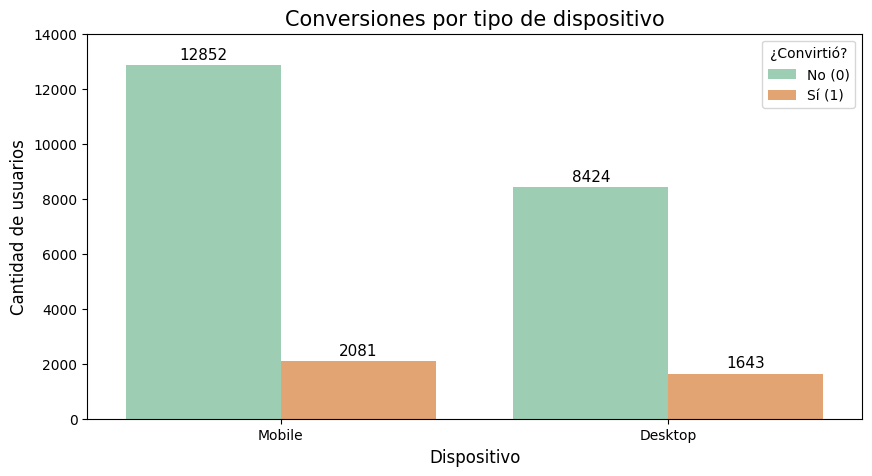

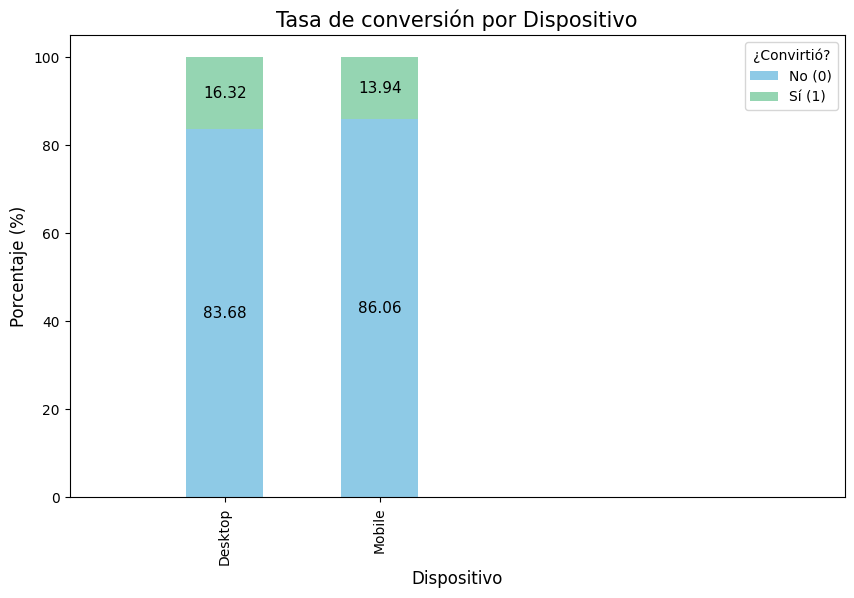

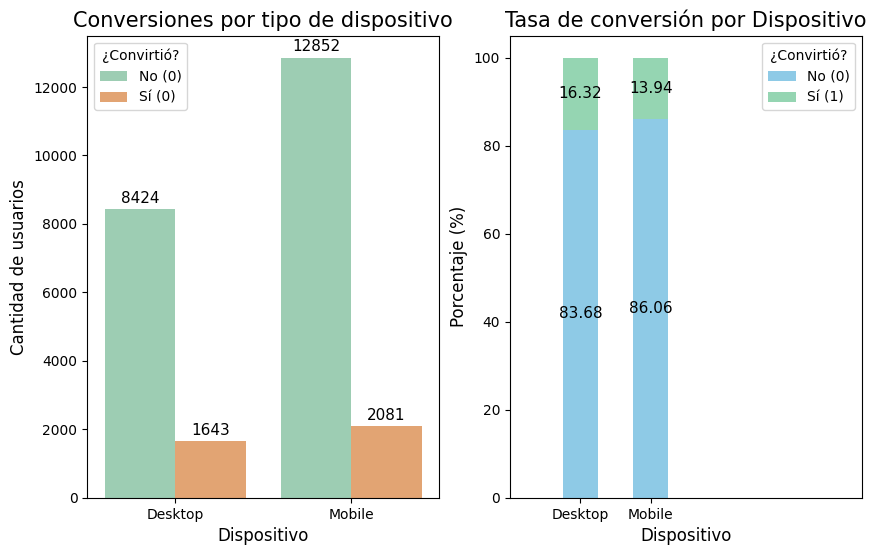

In [29]:
#Selecciona las columnas para aplicar la prueba chi-cuadrada

df_duplicado = df['id_usuario'].duplicated().sum()
df_par = df[['dispositivo','conversion']]

prueba_chi_cuadrado(df_duplicado, df_par, df['dispositivo'], df['conversion'],df)

1️⃣ ¿Hay evidencia de asociación?

“Con base en un chi-square test de independencia, encontramos evidencia estadística de que la conversión está asociada al dispositivo del usuario”.

2️⃣ ¿Cómo se manifiesta esa asociación?

Los usuarios de Desktop presentan una mayor proporción de conversión que los de Mobile.

Esto se obtiene de la tabla, no del valor p (p-value).

3️⃣ ¿Qué limitaciones o supuestos debo mencionar?

El resultado se basa en una muestra de usuarios.
La prueba evalúa asociación, no causalidad.
Algunas categorías pueden tener menor volumen de datos.
No se evalúa aquí el impacto práctico de segmentar decisiones.
💬 Ejemplo de conclusión completa
“Con base en un chi-square test de independencia, encontramos evidencia estadística de que la conversión está asociada al tipo de dispositivo.

En particular, los usuarios de Desktop muestran una mayor tasa de conversión que los de Mobile.

Este resultado se basa en una muestra de usuarios y no implica causalidad directa ni evalúa si esta diferencia justifica decisiones diferenciadas desde una perspectiva de negocio.”

### Segundo estudio: relación entre dispositivos y conversión con distribución de dispostivos desproporcionados

In [20]:
#Selecciona las columnas para aplicar la prueba chi-cuadrada

df_duplicado = df3['id_usuario'].duplicated().sum()
df_par = df3[['dispositivo','conversion']]

prueba_chi_cuadrado(df_duplicado, df_par, df3['dispositivo'], df3['conversion'], df3)

Se cumple primer criterio: no hay duplicados, conjunto de datos aptos para prueba chi-cuadrado

Tabla para la prueba de chi-cuadrado


conversion,0,1
dispositivo,,
Desktop,8416,1642
Mobile,12851,2080
Smart Speaker,2,4
Smart TV,3,2


Estadístico chi-cuadrdo: 42.311
Valor P: 0.000

Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.

Tabla normalizada


conversion,0,1
dispositivo,,
Desktop,83.67,16.33
Mobile,86.07,13.93
Smart Speaker,33.33,66.67
Smart TV,60.00,40.00


Frecuencias esperadas
[[8.5580e+03 1.5000e+03]
 [1.2704e+04 2.2270e+03]
 [5.0000e+00 1.0000e+00]
 [4.0000e+00 1.0000e+00]]

No se cumple el criterio: 
Al menos el 20% (resultado: 37.5) de las frecuencias esperadas son < 5. 
La prueba chi-cuadrada no es confiable para este conjunto de datos


### Continua segundo caso de estudio...
Derivado a que no se cumple el criterio de las frecuencias esperadas, se cambia el estudio con dos enfoques:

1.- Se filtra los dispositivos Smart TV y Smart Spearker (ya que representan menos del 1% del volumen total de datos).

2.- Se reagrupan los dispositivos Smart TV y Smart Spearker como "otros" y se aplica nuevamente la prueba

1.- Enfoque 1: se filtra Smart TV y Smart Speaker 

Se cumple primer criterio: no hay duplicados, conjunto de datos aptos para prueba chi-cuadrado

Tabla para la prueba de chi-cuadrado


conversion,0,1
dispositivo,,
Desktop,8416,1642
Mobile,12851,2080


Estadístico chi-cuadrdo: 26.996
Valor P: 0.000

Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.

Tabla normalizada


conversion,0,1
dispositivo,,
Desktop,83.67,16.33
Mobile,86.07,13.93


Frecuencias esperadas
[[ 8560.  1498.]
 [12707.  2224.]]

Se cumple el criterio: 
Al menos el 80% (Resultado: 100.0) de las frecuencias esperadas son >= 5


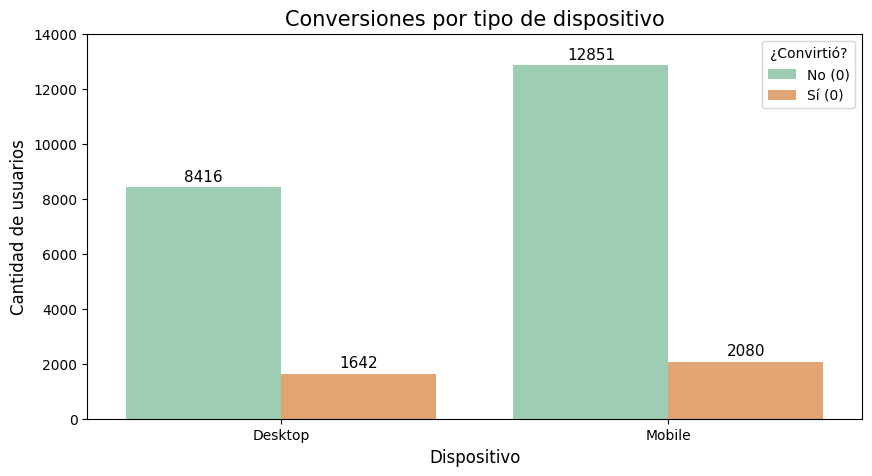

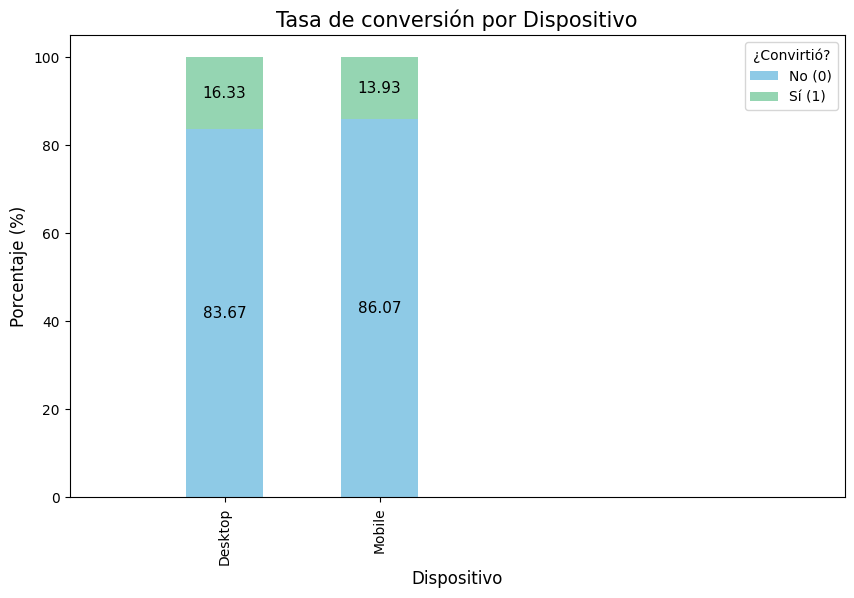

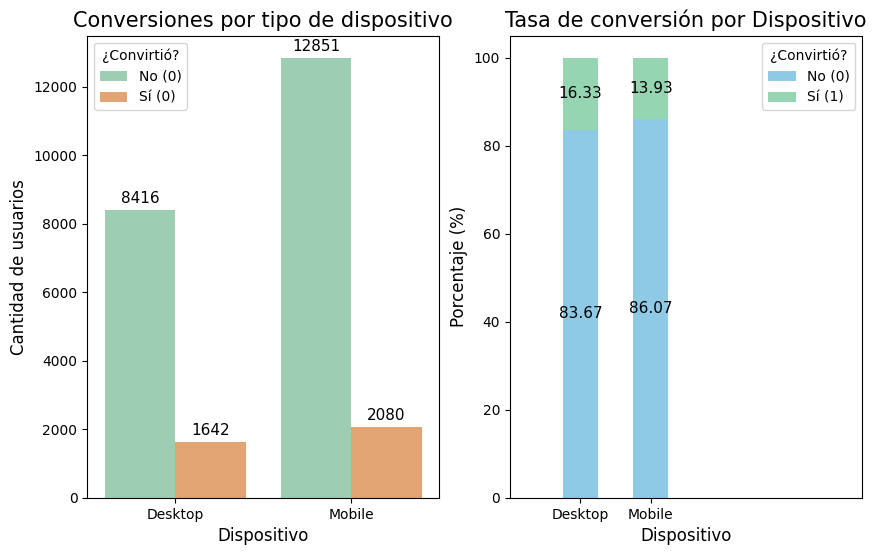

In [21]:

df_filtrado = df3[(df3['dispositivo'] != 'Smart Speaker')&(df3['dispositivo'] != 'Smart TV')]

df_duplicado = df3['id_usuario'].duplicated().sum()
df_par = df_filtrado[['dispositivo','conversion']]

prueba_chi_cuadrado(df_duplicado, df_par, df_filtrado['dispositivo'], df_filtrado['conversion'], df3)


### Continua segundo caso de estudio...

2.- Enfoque 2: Se reagrupan los dispositivos Smart TV y Smart Spearker como "otros" y se aplica nuevamente la prueba

Se cumple primer criterio: no hay duplicados, conjunto de datos aptos para prueba chi-cuadrado

Tabla para la prueba de chi-cuadrado


conversion,0,1
dispositivo_agrupado,,
Desktop,8416,1642
Mobile,12851,2080
Otros,5,6


Estadístico chi-cuadrdo: 40.782
Valor P: 0.000

Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.

Tabla normalizada


conversion,0,1
dispositivo_agrupado,,
Desktop,83.67,16.33
Mobile,86.07,13.93
Otros,45.45,54.55


Frecuencias esperadas
[[8.5580e+03 1.5000e+03]
 [1.2704e+04 2.2270e+03]
 [9.0000e+00 2.0000e+00]]

Se cumple el criterio: 
Al menos el 80% (Resultado: 83.33333333333334) de las frecuencias esperadas son >= 5


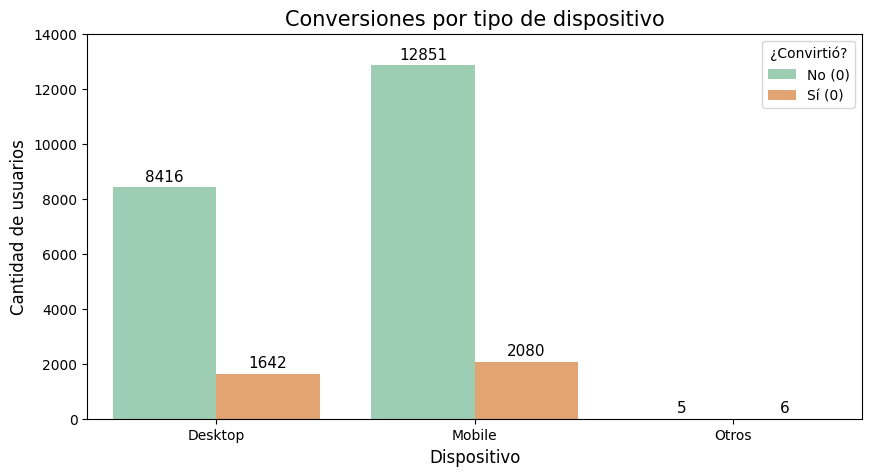

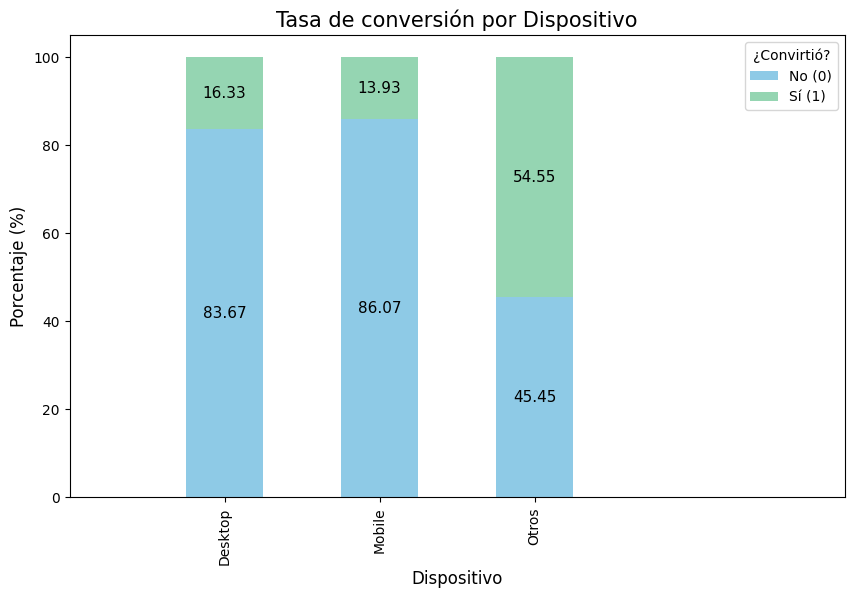

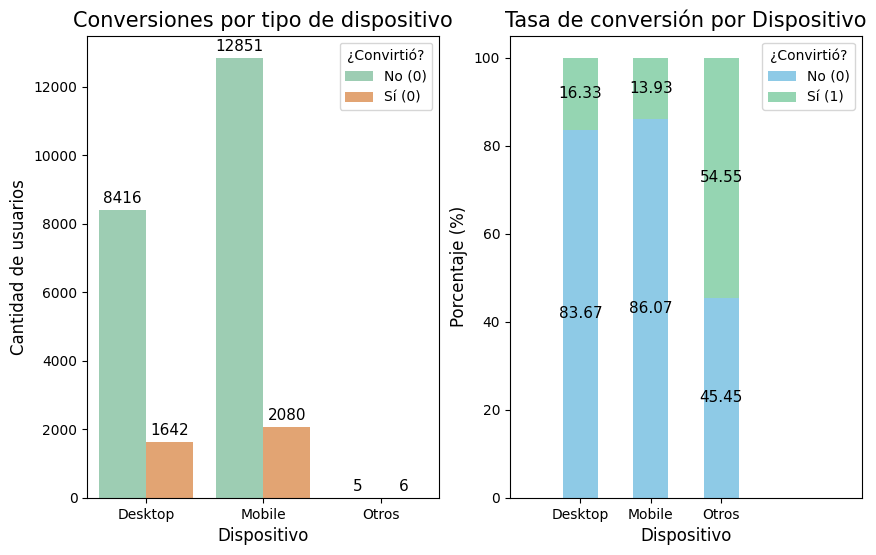

In [22]:

df3['dispositivo_agrupado'] = df3['dispositivo'].replace({'Smart Speaker':'Otros','Smart TV':'Otros'})

df_duplicado = df3['id_usuario'].duplicated().sum()
df_par = df3[['dispositivo_agrupado','conversion']]

prueba_chi_cuadrado(df_duplicado, df_par, df3['dispositivo_agrupado'], df3['conversion'], df3)



#### Conclusión:

Existe evidencia estadística de una cierta existencia de relación entre dispositivos y conversión, siendo una tendencia de conversión mayor por Desktop. Otro punto a resaltar, se observa en la gráfica de la izquierda que Mobile tiene un mayor numero de ingreso que Desktop, pero menor tasa de conversión. En la gráfica de la derecha se muestra que otros (Smart TV y Smar Speaker) tiene la mayor tasa de conversión, sin embargo, el ingreso de usarios son de 5 y 6.

### Tercer estudio: relación entre región y conversión con distribución proporcionados

2.- Enfoque 2: Se reagrupan los dispositivos Smart TV y Smart Spearker como "otros" y se aplica nuevamente la prueba

In [23]:
#Selecciona las columnas para aplicar la prueba chi-cuadrada

df_duplicado = df['id_usuario'].duplicated().sum()
df_par = df[['region','conversion']]

prueba_chi_cuadrado(df_duplicado, df_par, df['region'], df['conversion'],df)

Se cumple primer criterio: no hay duplicados, conjunto de datos aptos para prueba chi-cuadrado

Tabla para la prueba de chi-cuadrado


conversion,0,1
region,,
Centro,7380,1309
Norte,8620,1550
Sur,5276,865


Estadístico chi-cuadrdo: 4.331
Valor P: 0.115

No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.


#### Conclusión:

No hay evidencia estadística de que exista relación entre las variables